In [29]:
import pandas as pd
import numpy as np
import datetime

from sklearn.cluster import KMeans

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='darkgrid')

In [30]:
df = pd.read_csv("data/2855054_v1_data.csv")
df.head()

,SaleID,CustomerID,Quantity,ItemValue,SaleDate,ProductID,CardNumber,ItemDescription
0,358592764,922631,0.126,5.90,2025-01-01 06:06:55,99157,25847,sanduiche fpg-kg
1,358592764,922631,0.302,5.70,2025-01-01 06:06:55,99324,25847,mini pao c/fibras fpg- kg
2,358593505,0,0.068,2.50,2025-01-01 06:14:51,46907,0,broa fpg-kg rapadura
3,358593505,0,1.000,6.49,2025-01-01 06:14:51,99128,0,choc ao leite talento 90g-tb cookies
4,358593505,0,1.000,2.99,2025-01-01 06:14:51,100466,0,bala fruittella gelato 41g-un fruta vermelha


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189107 entries, 0 to 189106
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   SaleID           189107 non-null  int64  
 1   CustomerID       189107 non-null  int64  
 2   Quantity         189107 non-null  float64
 3   ItemValue        189107 non-null  float64
 4   SaleDate         189107 non-null  str    
 5   ProductID        189107 non-null  int64  
 6   CardNumber       189107 non-null  int64  
 7   ItemDescription  189107 non-null  str    
dtypes: float64(2), int64(4), str(2)
memory usage: 11.5 MB


In [32]:
# remove rows with nulls in the essential columns for RFM calculation
# Recency = SaleDate
# Frequency = SaleDate (once per customer x date)
# Monetary = ItemValue
df = df.dropna(subset=['CustomerID', 'ItemValue', 'SaleDate', 'ItemDescription'])
df.shape

(189107, 8)

In [33]:
# Remove generic customer (CustomerID=0)
# RFM focuses on loyal and identified customers
df = df[df["CustomerID"] != 0]
df.shape

(115144, 8)

In [34]:
# Convert date field to date
df["SaleDate"] = pd.to_datetime(df["SaleDate"])

In [35]:
# Remove duplicated products in the same purchase
# remove inflated sum of monetary
df = df.drop_duplicates(subset=['SaleID', 'CustomerID', 'ProductID'])
df.shape

(103799, 8)

In [36]:
# one date per transaction
df.groupby('SaleID').SaleDate.nunique().sort_values()

SaleID
358592764    1
358593671    1
358594378    1
358594495    1
358594688    1
            ..
408182787    1
408182803    1
408183309    1
408183760    1
408185737    1
Name: SaleDate, Length: 37713, dtype: int64

In [37]:
df_rfm = df[['CustomerID', 'SaleDate', 'ItemValue']].copy()

In [38]:
# define the reference day for Recency
# use the date of the last transaction + 1, to ensure recency is >= 1 day
reference_date = df_rfm["SaleDate"].max() + datetime.timedelta(days=1)

In [39]:
rfm = df_rfm.groupby("CustomerID").agg(
    Recency=('SaleDate', lambda date: (reference_date - date.max()).days),
    Frequency=('SaleDate', 'nunique'), # number of unique transactions
    # Frequency=('SaleID', 'nunique')
    Monetary=('ItemValue', 'sum'), # total amount spent
).reset_index()
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,42476,74,2,45.77
1,46285,2,4,534.93
2,53865,83,1,99.84
3,78795,65,1,12.89
4,83592,103,1,8.17


Text(0, 0.5, 'Customer count')

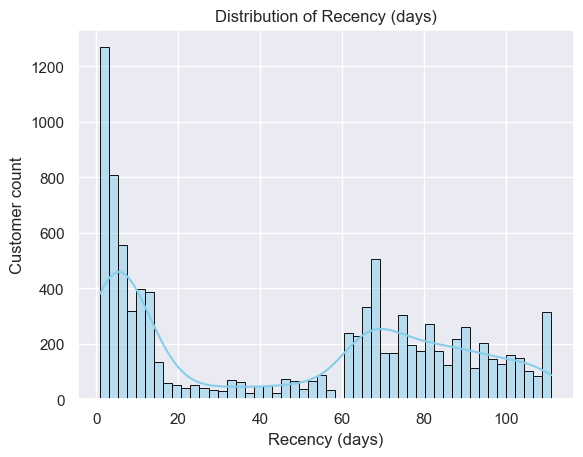

In [40]:
sns.histplot(data=rfm['Recency'], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Recency (days)')
plt.xlabel('Recency (days)')
plt.ylabel('Customer count')

(0.0, 28.0)

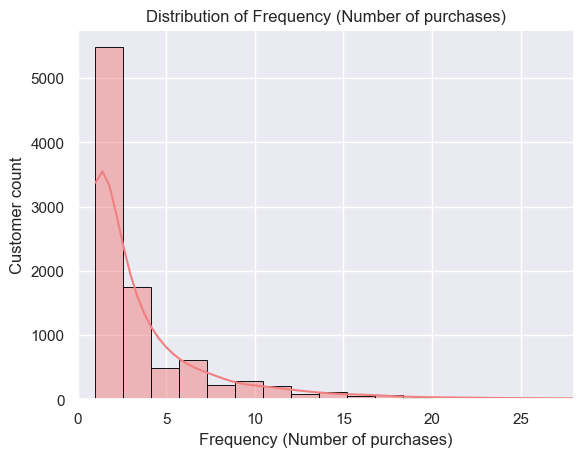

In [41]:
sns.histplot(data=rfm['Frequency'], bins=50, kde=True, color='lightcoral', edgecolor='black')
plt.title('Distribution of Frequency (Number of purchases)')
plt.xlabel('Frequency (Number of purchases)')
plt.ylabel('Customer count')
plt.xlim(0, rfm['Frequency'].quantile(.99)) # better visualization

(0.0, 1000.122000000001)

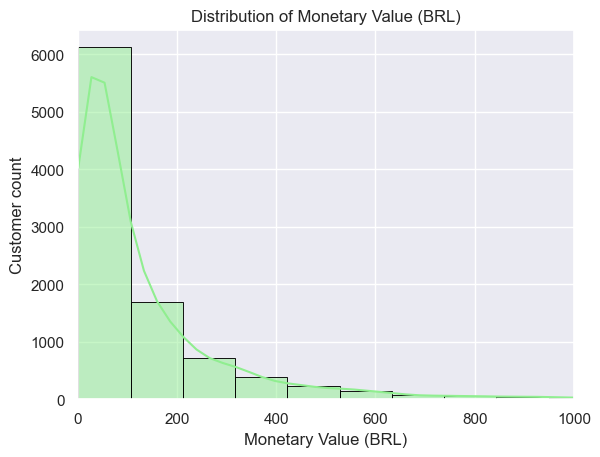

In [42]:
sns.histplot(data=rfm['Monetary'], bins=50, kde=True, color='lightgreen', edgecolor='black')
plt.title('Distribution of Monetary Value (BRL)')
plt.xlabel('Monetary Value (BRL)')
plt.ylabel('Customer count')
plt.xlim(0, rfm['Monetary'].quantile(.99)) # better visualization

## Clustering

In [43]:
(rfm == 0).sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

In [44]:
# apply log to mitigate skewness, assuming no zero values
rfm_transformed = rfm[['Recency', 'Frequency', 'Monetary']].copy()
#rfm_transformed['Recency'] = np.log(rfm_transformed['Recency']) # data is not skewed
rfm_transformed['Frequency'] = np.log(rfm_transformed['Frequency'])
rfm_transformed['Monetary'] = np.log(rfm_transformed['Monetary'])

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_transformed)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm_transformed.columns)
rfm_scaled.head

<bound method NDFrame.head of        Recency  Frequency  Monetary
0     0.703336  -0.210502 -0.298357
1    -1.188830   0.559509  1.681780
2     0.939857  -0.980514  0.329824
3     0.466816  -0.980514 -1.318970
4     1.465459  -0.980514 -1.686229
...        ...        ...       ...
9568 -1.215111  -0.210502  0.048429
9569 -1.083710  -0.980514 -0.166520
9570 -1.162550  -0.210502  0.339208
9571 -1.136270  -0.980514  0.098871
9572 -1.188830  -0.980514 -1.383334

[9573 rows x 3 columns]>

In [46]:
from sklearn.cluster import KMeans

k_range = range(1, 11)

inertia = [] # (Within-Cluster Sum of Squares)
for k in k_range:
    # n_init runs the algorithm multiple times and return the best results
    # (change initial centroids)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

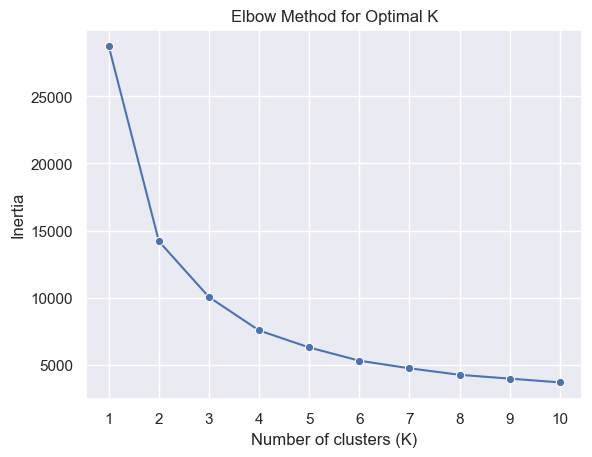

In [47]:
sns.lineplot(x=k_range, y=inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range);

In [48]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5, 6, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    score = silhouette_score(rfm_scaled, kmeans.fit_predict(rfm_scaled))
    print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=3: 0.4018
Silhouette Score for k=4: 0.3978
Silhouette Score for k=5: 0.3632
Silhouette Score for k=6: 0.3374
Silhouette Score for k=7: 0.3223


Com base na análise de cotovelo, podem ser selecionados 3 ou 4 clusters a depender da estratégia que melhor se adequar a situação. Ambos possuem valores de 'Silhouette Score' muito próximos e estão próximos da região do 'cotovelo'.

**As análises seguindo serão realizadas com k=3.**

In [49]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [50]:
rfm_summarized = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].agg(['mean', 'median', 'std', 'count'])
rfm_summarized

Recency                         Frequency                         \
              mean median        std count      mean median       std count   
Cluster                                                                       
0        11.178938    8.0  10.881204  2146  1.946878    2.0  0.988970  2146   
1        19.924681    7.0  24.872505  2974  8.956624    7.0  7.735525  2974   
2        82.854929   82.0  15.789142  4453  1.548843    1.0  0.870375  4453   

           Monetary                             
               mean   median         std count  
Cluster                                         
0         56.505531   46.535   44.355411  2146  
1        324.665508  234.345  311.276746  2974  
2         52.487871   36.490   53.179837  4453

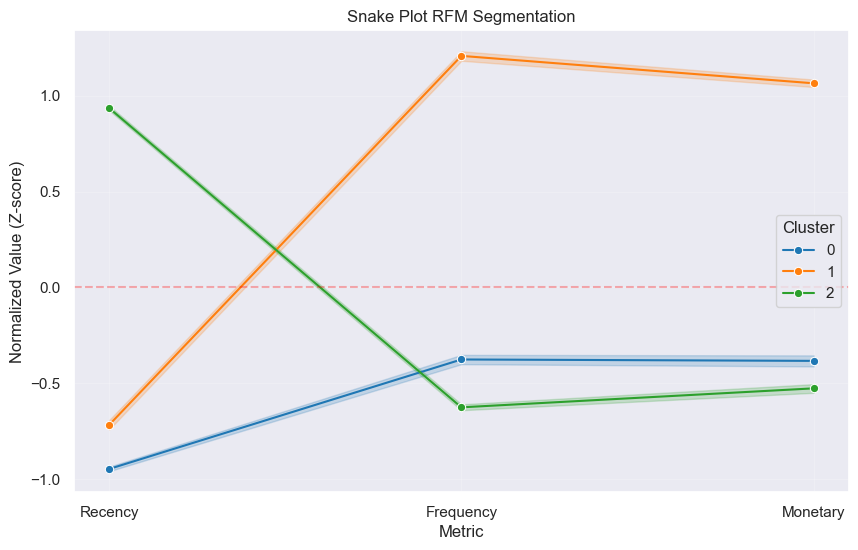

In [51]:
rfm_scaled_with_cluster = rfm_scaled.copy()
rfm_scaled_with_cluster['Cluster'] = kmeans.fit_predict(rfm_scaled)

df_melt = pd.melt(rfm_scaled_with_cluster, 
                  id_vars=['Cluster'],
                  value_vars=['Recency', 'Frequency', 'Monetary'], 
                  var_name='Metric', 
                  value_name='Value')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melt, x='Metric', y='Value', hue='Cluster', palette='tab10', marker='o')
plt.title('Snake Plot RFM Segmentation')
plt.xlabel('Metric')
plt.ylabel('Normalized Value (Z-score)')

# Adicionar uma linha na média (0) para referência
plt.axhline(0, ls='--', c='red', alpha=0.3)
plt.grid(True, alpha=0.2)
plt.show()

Com este gráfico fica simples de ver como se comporta os 3 grupos:

1. **Grupo 0 (Novos/Promissores):** Realizaram compras recentes, mas a frequência e valor gasto são medianos.
2. **Grupo 1 (Champions):** São os clientes mais promissores, possuem baixa recência, porém alta frequência e gastos monetários.
3. **Grupo 2 (Em Risco/Hibernando):** São clientes considerados em risco, porque fizeram compra a muito tempo atrás, possui baixa frequência e gasto.

In [52]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = pca_components[:, 0]
rfm['PCA2'] = pca_components[:, 1]

Text(0, 0.5, 'Principal Component 2')

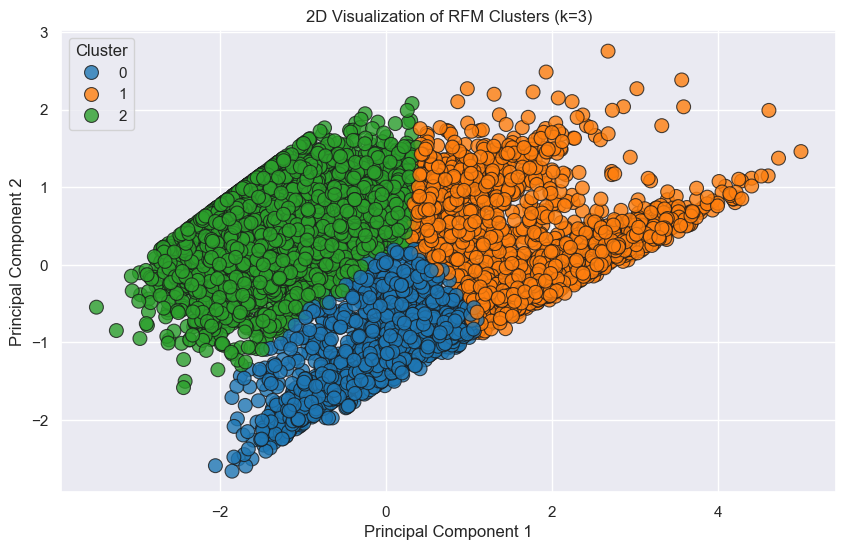

In [53]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=100, edgecolor='k', alpha=.8)
plt.title('2D Visualization of RFM Clusters (k=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

In [54]:
cluster_map = {
    0: 'Novos/Promissores',
    1: 'Champions',
    2: 'Em Risco/Hibernando'
}

rfm["Cluster Name"] = rfm["Cluster"].map(cluster_map)

In [55]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,PCA1,PCA2,Cluster Name
0,42476,74,2,45.77,2,-0.662586,0.408518,Em Risco/Hibernando
1,46285,2,4,534.93,1,1.950363,-0.086236,Champions
2,53865,83,1,99.84,2,-0.888527,0.730361,Em Risco/Hibernando
3,78795,65,1,12.89,2,-1.635491,-0.452585,Em Risco/Hibernando
4,83592,103,1,8.17,2,-2.355420,0.222743,Em Risco/Hibernando


## Conclusão

Com essa segmentação dos clientes é possível montar estratégias de como lidar com cada segmento. Permitindo a equipe de marketing lidar de forma mais informada com os diferentes segmentos de clientes.

As recomendações de ações por segmentos são:

1. **Novos/Promissores:** Estratégia de `nutrição` para incentivar a segunda compra e transformar um comprador ocasional em um cliente recorrente.
2. **Champions:** Estratégia de `fidelização` para manter os melhores clientes e transformá-los em defensores da marca.
3. **Em Risco/Hibernando:** Estratégia de `reativação` para reconquistar clientes que se afastaram e entender o motivo da inatividade.